# Cross-Session Boundary Transition Analysis

This notebook computes **cross-session boundary transitions** across repositories:
- Source intent `close_i`: labels of the **last message** in a session
- Target intent `open_j`: labels of the **first message** in the next chronological session (same repo)

We use the same weighted multi-label transition logic as in-session analysis:
- For a boundary pair, enumerate Cartesian product `L_close x L_open`
- Weight each pair by `1 / (|L_close| x |L_open|)` so each boundary contributes exactly 1.0

Cross-session boundary lift is defined as:
`lift_boundary(i -> j) = P(open_j | close_i) / P(open_j)`

## 1. Imports & Setup

In [1]:
import sys
from pathlib import Path

sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from intent_classification.categories import VALID_CATEGORIES

RESULTS_DIR = Path("cross_session_results")
RESULTS_DIR.mkdir(exist_ok=True)

MAIN_ORDER = [m for m in VALID_CATEGORIES.keys() if not m.startswith("8.")]
SUB_ORDER = [s for m in MAIN_ORDER for s in VALID_CATEGORIES[m]]

print(f"Main categories ({len(MAIN_ORDER)}): {MAIN_ORDER}")
print(f"Sub categories ({len(SUB_ORDER)}): {SUB_ORDER}")
print(f"Saving outputs to: {RESULTS_DIR.resolve()}")

Main categories (7): ['1. Code Authoring', '2. Failure Reporting', '3. Inquiry', '4. Context Specification', '5. Validation', '6. Delegation', '7. Workflow Control']
Sub categories (20): ['1.1 New Implementation', '1.2 Iterative Modification', '1.3 Alignment Correction', '2.1 Log Paste', '2.2 Symptom Description', '2.3 Error Persistence', '3.1 Planning & Decision Consultation', '3.2 Project Comprehension', '3.3 General Knowledge Query', '4.1 Information Injection', '4.2 Behavior Specification', '5.1 Code Review', '5.2 Runtime Inspection', '6.1 Documentation', '6.2 Toolchain Operation', '7.1 Confirmation', '7.2 Continuation', '7.3 Deferred Debugging', '7.4 Deferred Implementation', '7.5 Sentiment Expression']
Saving outputs to: /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/markov_transition/cross_session_results


## 2. Load Data and Build Message-Level Label Sets

In [ ]:
df = pd.read_csv("../data/classifications/classifications_for_analysis.csv")

required_cols = [
    "repository_full_name",
    "sha",
    "timestamp",
    "index_in_chat",
    "main_category",
    "sub_category",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Parse timestamp for deterministic chronological ordering.
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

print(f"Loaded rows: {len(df)}")
print(f"Unique repos: {df['repository_full_name'].nunique()}")
print(f"Unique sessions (sha): {df['sha'].nunique()}")
print(f"Unique messages: {df[['sha', 'index_in_chat']].drop_duplicates().shape[0]}")
print(f"Missing timestamps: {df['timestamp'].isna().sum()}")

msg_sub_labels = (
    df.groupby(["repository_full_name", "sha", "timestamp", "index_in_chat"])[
        "sub_category"
    ]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index()
    .rename(columns={"sub_category": "sub_labels"})
)

msg_main_labels = (
    df.groupby(["repository_full_name", "sha", "timestamp", "index_in_chat"])[
        "main_category"
    ]
    .apply(lambda x: tuple(sorted(set(x))))
    .reset_index()
    .rename(columns={"main_category": "main_labels"})
)

msg_df = msg_sub_labels.merge(
    msg_main_labels,
    on=["repository_full_name", "sha", "timestamp", "index_in_chat"],
)

msg_df = msg_df.sort_values(
    ["repository_full_name", "sha", "index_in_chat"]
).reset_index(drop=True)

print(f"Message-level rows: {len(msg_df)}")
print("Sample rows:")
print(msg_df.head())

Loaded rows: 99415
Unique repos: 1300
Unique sessions (sha): 11579
Unique messages: 74998
Missing timestamps: 0
Message-level rows: 74998
Sample rows:
  repository_full_name                                       sha  \
0         13jden/JieYa  092db00b64c22fba79c2801f3563c3d4ca432409   
1         13jden/JieYa  092db00b64c22fba79c2801f3563c3d4ca432409   
2         13jden/JieYa  092db00b64c22fba79c2801f3563c3d4ca432409   
3         13jden/JieYa  092db00b64c22fba79c2801f3563c3d4ca432409   
4         13jden/JieYa  092db00b64c22fba79c2801f3563c3d4ca432409   

                  timestamp  index_in_chat  \
0 2025-03-29 11:03:00+00:00              0   
1 2025-03-29 11:03:00+00:00              1   
2 2025-03-29 11:03:00+00:00              2   
3 2025-03-29 11:03:00+00:00              3   
4 2025-03-29 11:03:00+00:00              4   

                                          sub_labels  \
0                      (1.2 Iterative Modification,)   
1                      (1.2 Iterative Modification,

## 3. Build Cross-Session Close/Open Boundary Pairs

In [ ]:
# Session metadata (one row per session)
session_meta = (
    msg_df[["repository_full_name", "sha", "timestamp"]]
    .drop_duplicates()
    .sort_values(["repository_full_name", "timestamp", "sha"], na_position="last")
    .reset_index(drop=True)
)

repo_session_counts = session_meta.groupby("repository_full_name")["sha"].nunique()
valid_repos = repo_session_counts[repo_session_counts >= 2].index

session_meta = session_meta[
    session_meta["repository_full_name"].isin(valid_repos)
].copy()
session_meta["session_rank"] = session_meta.groupby("repository_full_name").cumcount()

# Per-session opening and closing messages.
session_open = (
    msg_df.sort_values(["repository_full_name", "sha", "index_in_chat"])
    .groupby(["repository_full_name", "sha", "timestamp"], as_index=False)
    .first()[["repository_full_name", "sha", "timestamp", "main_labels", "sub_labels"]]
    .rename(
        columns={"main_labels": "open_main_labels", "sub_labels": "open_sub_labels"}
    )
)

session_close = (
    msg_df.sort_values(["repository_full_name", "sha", "index_in_chat"])
    .groupby(["repository_full_name", "sha", "timestamp"], as_index=False)
    .last()[["repository_full_name", "sha", "timestamp", "main_labels", "sub_labels"]]
    .rename(
        columns={"main_labels": "close_main_labels", "sub_labels": "close_sub_labels"}
    )
)

session_state = session_meta.merge(
    session_open, on=["repository_full_name", "sha", "timestamp"], how="left"
).merge(session_close, on=["repository_full_name", "sha", "timestamp"], how="left")

# Build adjacent pairs within each repository: prev session close -> next session open.
prev_state = session_state.copy()
next_state = session_state.copy()
next_state["session_rank"] = next_state["session_rank"] - 1

boundary_pairs = prev_state.merge(
    next_state,
    on=["repository_full_name", "session_rank"],
    suffixes=("_prev", "_next"),
)

boundary_pairs = boundary_pairs[
    [
        "repository_full_name",
        "sha_prev",
        "timestamp_prev",
        "close_main_labels_prev",
        "close_sub_labels_prev",
        "sha_next",
        "timestamp_next",
        "open_main_labels_next",
        "open_sub_labels_next",
    ]
]

boundary_pairs = boundary_pairs.rename(
    columns={
        "close_main_labels_prev": "close_main_labels",
        "close_sub_labels_prev": "close_sub_labels",
        "open_main_labels_next": "open_main_labels",
        "open_sub_labels_next": "open_sub_labels",
    }
).reset_index(drop=True)

print(f"Repos total: {df['repository_full_name'].nunique()}")
print(f"Repos with >=2 sessions: {len(valid_repos)}")
print(
    f"Single-session repos excluded: {df['repository_full_name'].nunique() - len(valid_repos)}"
)
print(f"Boundary pairs (close->open): {len(boundary_pairs)}")
print("\nSample boundary pairs:")
print(boundary_pairs.head())

Repos total: 1300
Repos with >=2 sessions: 801
Single-session repos excluded: 499
Boundary pairs (close->open): 10279

Sample boundary pairs:
  repository_full_name                                  sha_prev  \
0         13jden/JieYa  3ea404607f30d92cafc36611940e93b32666d2a2   
1         13jden/JieYa  8cb729e05e6d4634b3f40de99d2ccb59fbf3f807   
2         13jden/JieYa  c82ff89945771847bdeab3a1e8c71bdc05de411a   
3         13jden/JieYa  2084b902f34b427a8b5049fa6af266180fd7d3bc   
4         13jden/JieYa  b32013f3002e36a072848dbc5944716fbaafbe34   

             timestamp_prev                              close_main_labels  \
0 2025-03-12 15:33:00+00:00                           (1. Code Authoring,)   
1 2025-03-13 16:10:00+00:00  (1. Code Authoring, 4. Context Specification)   
2 2025-03-13 16:10:00+00:00                           (1. Code Authoring,)   
3 2025-03-16 07:11:00+00:00                           (1. Code Authoring,)   
4 2025-03-16 12:46:00+00:00                           (1. C

## 4. Weighted Boundary Transition Counting

In [ ]:
def compute_weighted_boundary_transitions(boundary_df, close_col, open_col, categories):
    """
    Compute weighted boundary transition counts for close->open session transitions.

    Each boundary contributes total 1.0 mass distributed across Cartesian product.
    """
    cat2idx = {c: i for i, c in enumerate(categories)}
    n = len(categories)
    C = np.zeros((n, n), dtype=np.float64)

    for _, row in boundary_df.iterrows():
        L_close = row[close_col]
        L_open = row[open_col]

        if not isinstance(L_close, tuple) or not isinstance(L_open, tuple):
            continue
        if len(L_close) == 0 or len(L_open) == 0:
            continue

        w = 1.0 / (len(L_close) * len(L_open))
        for src in L_close:
            for tgt in L_open:
                if src in cat2idx and tgt in cat2idx:
                    C[cat2idx[src], cat2idx[tgt]] += w

    C_df = pd.DataFrame(C, index=categories, columns=categories)
    return C_df


C_main = compute_weighted_boundary_transitions(
    boundary_pairs,
    close_col="close_main_labels",
    open_col="open_main_labels",
    categories=MAIN_ORDER,
)

C_sub = compute_weighted_boundary_transitions(
    boundary_pairs,
    close_col="close_sub_labels",
    open_col="open_sub_labels",
    categories=SUB_ORDER,
)

n_boundaries = len(boundary_pairs)
print(f"Boundary pairs: {n_boundaries}")
print(
    f"Main count matrix sum: {C_main.values.sum():.3f} (should approx {n_boundaries})"
)
print(f"Sub count matrix sum: {C_sub.values.sum():.3f} (should approx {n_boundaries})")

Boundary pairs: 10279
Main count matrix sum: 10279.000 (should approx 10279)
Sub count matrix sum: 10279.000 (should approx 10279)


## 5. Opening Marginals and Boundary Lift

In [ ]:
def compute_opening_marginals(boundary_df, open_col, categories):
    """Compute P(open_j) from opening labels in boundary successor sessions."""
    counts = {c: 0.0 for c in categories}
    total = 0.0

    for labels in boundary_df[open_col]:
        if not isinstance(labels, tuple) or len(labels) == 0:
            continue
        w = 1.0 / len(labels)
        for label in labels:
            if label in counts:
                counts[label] += w
        total += 1.0

    if total == 0:
        return pd.Series({c: np.nan for c in categories}, dtype=np.float64)

    return pd.Series({c: counts[c] / total for c in categories}, dtype=np.float64)


def compute_conditional_and_lift(C_df, marginals):
    row_sums = C_df.sum(axis=1)
    P_cond = C_df.div(row_sums, axis=0).fillna(0)
    lift = P_cond.div(marginals, axis=1).replace([np.inf, -np.inf], np.nan)
    return P_cond, lift


P_open_main = compute_opening_marginals(boundary_pairs, "open_main_labels", MAIN_ORDER)
P_open_sub = compute_opening_marginals(boundary_pairs, "open_sub_labels", SUB_ORDER)

P_cond_main, lift_main = compute_conditional_and_lift(C_main, P_open_main)
P_cond_sub, lift_sub = compute_conditional_and_lift(C_sub, P_open_sub)

print(f"Opening marginals sum (main): {P_open_main.sum():.6f}")
print(f"Opening marginals sum (sub): {P_open_sub.sum():.6f}")

print("\nRow sums of P(open_j|close_i) at main level:")
print(P_cond_main.sum(axis=1).round(6).to_string())

print("\nRow sums of P(open_j|close_i) at sub level:")
print(P_cond_sub.sum(axis=1).round(6).to_string())

Opening marginals sum (main): 1.000000
Opening marginals sum (sub): 1.000000

Row sums of P(open_j|close_i) at main level:
1. Code Authoring           1.0
2. Failure Reporting        1.0
3. Inquiry                  1.0
4. Context Specification    1.0
5. Validation               1.0
6. Delegation               1.0
7. Workflow Control         1.0

Row sums of P(open_j|close_i) at sub level:
1.1 New Implementation                  1.0
1.2 Iterative Modification              1.0
1.3 Alignment Correction                1.0
2.1 Log Paste                           1.0
2.2 Symptom Description                 1.0
2.3 Error Persistence                   1.0
3.1 Planning & Decision Consultation    1.0
3.2 Project Comprehension               1.0
3.3 General Knowledge Query             1.0
4.1 Information Injection               1.0
4.2 Behavior Specification              1.0
5.1 Code Review                         1.0
5.2 Runtime Inspection                  1.0
6.1 Documentation                   

## 6. Save Required Cross-Session Outputs

In [ ]:
TRANSITION_DATA_DIR = RESULTS_DIR / "transition_matrices"
TRANSITION_DATA_DIR.mkdir(parents=True, exist_ok=True)


def save_required_outputs(level_key, lift_df, marginals):
    level_dir = TRANSITION_DATA_DIR / level_key
    level_dir.mkdir(parents=True, exist_ok=True)

    lift_df.to_csv(level_dir / "transition_lift.csv", index=True)
    marginals.rename("marginal").to_csv(level_dir / "marginals.csv", index=True)
    return level_dir


main_dir = save_required_outputs("main_category", lift_main, P_open_main)
sub_dir = save_required_outputs("sub_category", lift_sub, P_open_sub)

print(f"Saved cross-session outputs to: {TRANSITION_DATA_DIR.resolve()}")
print("Each level saves only: transition_lift.csv, marginals.csv")
print(f"- Main: {main_dir}")
print(f"- Sub: {sub_dir}")

Saved cross-session outputs to: /Users/ningzhi_tang/Documents/VSCodeProjects/empirical-conversational-programming/markov_transition/cross_session_results/transition_matrices
Each level saves only: transition_lift.csv, marginals.csv
- Main: cross_session_results/transition_matrices/main_category
- Sub: cross_session_results/transition_matrices/sub_category


## 7. Heatmaps (Cross-Session Boundary)

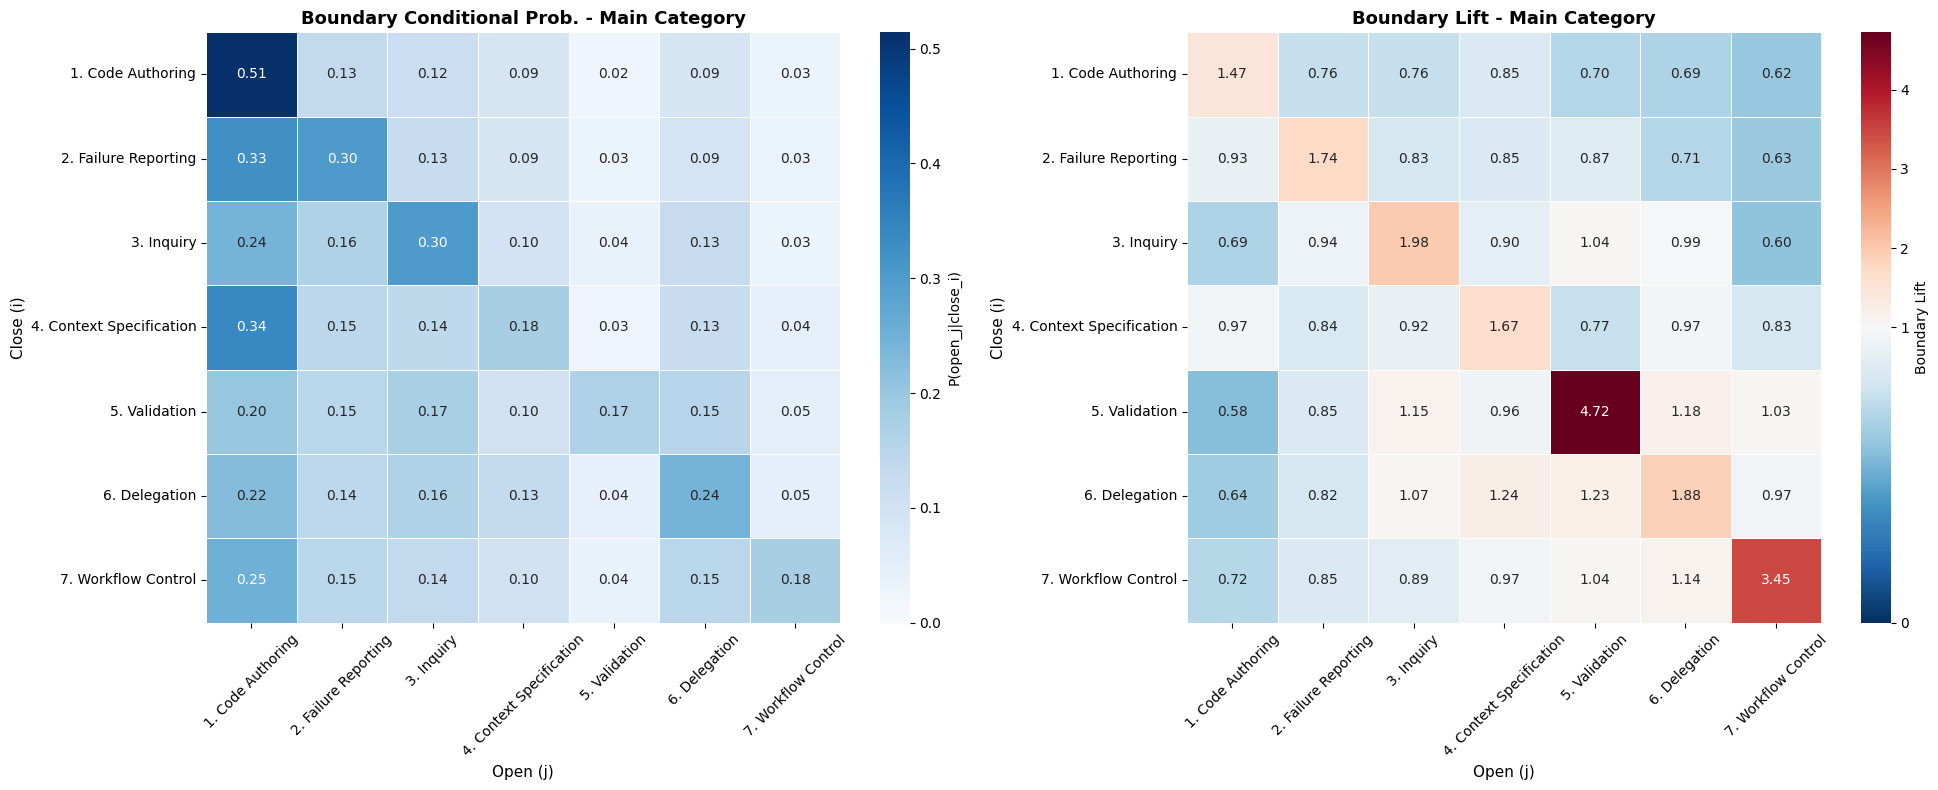

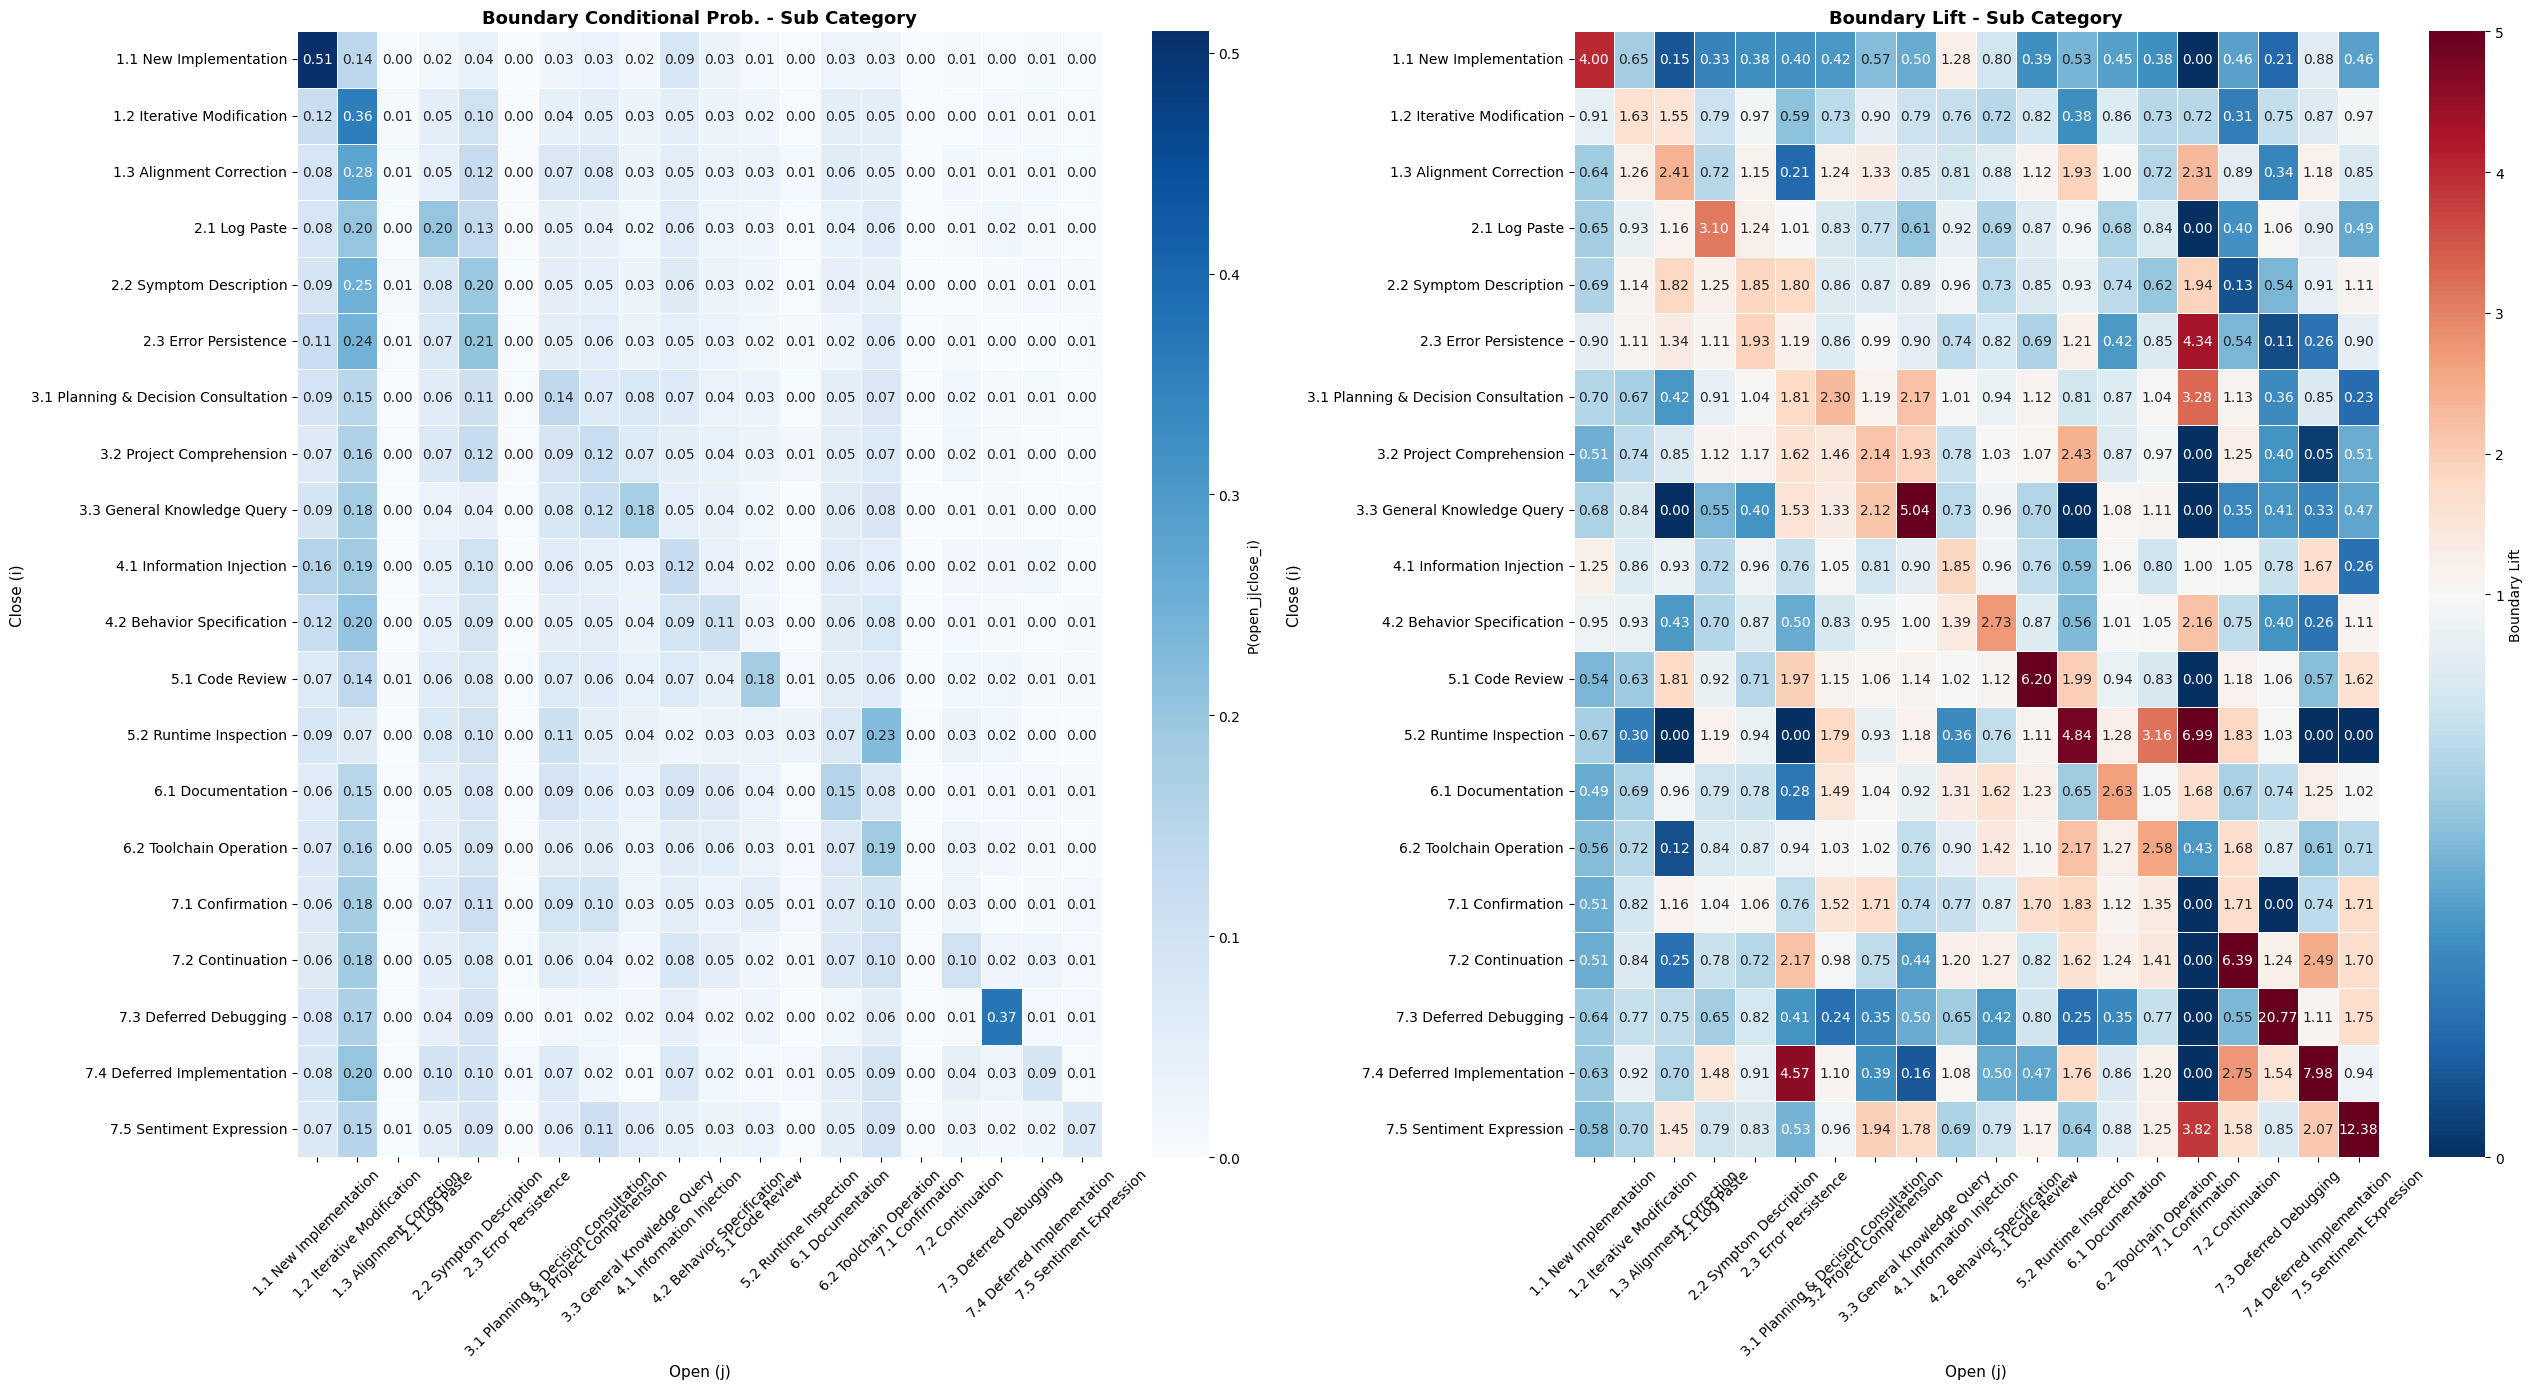

In [ ]:
def plot_heatmaps(P_cond, lift, categories, level_name, figsize=(18, 7)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    ax = axes[0]
    sns.heatmap(
        P_cond,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        vmin=0,
        cbar_kws={"label": "P(open_j|close_i)"},
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(
        f"Boundary Conditional Prob. - {level_name}", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Open (j)", fontsize=11)
    ax.set_ylabel("Close (i)", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    ax = axes[1]
    vals = lift.values[np.isfinite(lift.values)]
    vmax_raw = float(vals.max()) if vals.size else 2.0
    vmax = max(2.0, min(vmax_raw, 5.0))
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=vmax)

    sns.heatmap(
        lift,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        norm=norm,
        xticklabels=categories,
        yticklabels=categories,
        ax=ax,
        cbar_kws={"label": "Boundary Lift"},
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(f"Boundary Lift - {level_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Open (j)", fontsize=11)
    ax.set_ylabel("Close (i)", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR
        / f"heatmap_cross_session_{level_name.lower().replace(' ', '_')}.pdf",
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()


plot_heatmaps(P_cond_main, lift_main, MAIN_ORDER, "Main Category", figsize=(20, 8))
plot_heatmaps(P_cond_sub, lift_sub, SUB_ORDER, "Sub Category", figsize=(26, 14))

## 8. Diagonal vs Non-Diagonal Transition Report

In [ ]:
def build_transition_table(P_cond, lift_matrix, C_df, categories, level_name, top_n=20):
    records = []
    for src in categories:
        for tgt in categories:
            p = P_cond.loc[src, tgt]
            lft = lift_matrix.loc[src, tgt]
            c = C_df.loc[src, tgt]
            records.append(
                {
                    "source": src,
                    "target": tgt,
                    "count": round(float(c), 4),
                    "P(open_j|close_i)": round(float(p), 6),
                    "lift": round(float(lft), 6) if pd.notna(lft) else np.nan,
                    "type": "diagonal" if src == tgt else "non-diagonal",
                }
            )

    table = pd.DataFrame(records)
    table = table[table["count"] > 0].copy()
    table = table.sort_values("lift", ascending=False).reset_index(drop=True)

    print(f"\n{'='*110}")
    print(f"Top {top_n} transitions by boundary lift - {level_name}")
    print(f"{'='*110}")
    print(table.head(top_n).to_string(index=False))

    print(f"\n{'='*110}")
    print(f"Bottom {top_n} transitions by boundary lift - {level_name}")
    print(f"{'='*110}")
    print(table.tail(top_n).to_string(index=False))

    diag = table[table["type"] == "diagonal"].copy()
    nondiag = table[table["type"] == "non-diagonal"].copy()

    print(f"\n{'='*110}")
    print(f"Top {top_n} diagonal transitions - {level_name}")
    print(f"{'='*110}")
    print(diag.head(top_n).to_string(index=False))

    print(f"\n{'='*110}")
    print(f"Top {top_n} non-diagonal transitions - {level_name}")
    print(f"{'='*110}")
    print(nondiag.head(top_n).to_string(index=False))

    print(
        f"\nNon-zero transitions: {len(table)} ({len(diag)} diagonal, {len(nondiag)} non-diagonal)"
    )

    return table


table_main = build_transition_table(
    C_df=C_main,
    P_cond=P_cond_main,
    lift_matrix=lift_main,
    categories=MAIN_ORDER,
    level_name="Main Category",
    top_n=20,
)
table_sub = build_transition_table(
    C_df=C_sub,
    P_cond=P_cond_sub,
    lift_matrix=lift_sub,
    categories=SUB_ORDER,
    level_name="Sub Category",
    top_n=20,
)


Top 20 transitions by boundary lift - Main Category
                  source                   target     count  P(open_j|close_i)     lift         type
           5. Validation            5. Validation   44.4722           0.167346 4.722445     diagonal
     7. Workflow Control      7. Workflow Control  192.8333           0.178068 3.449724     diagonal
              3. Inquiry               3. Inquiry  355.6250           0.302788 1.982986     diagonal
           6. Delegation            6. Delegation  395.2917           0.243294 1.877796     diagonal
    2. Failure Reporting     2. Failure Reporting  603.0556           0.302992 1.741428     diagonal
4. Context Specification 4. Context Specification  150.0306           0.177114 1.671463     diagonal
       1. Code Authoring        1. Code Authoring 1693.7389           0.514241 1.466183     diagonal
           6. Delegation 4. Context Specification  213.9167           0.131661 1.242514 non-diagonal
           6. Delegation            5.

## 9. Compare with In-Session Results and Interpret Boundary Meaningfulness

In [ ]:
IN_SESSION_DIR = Path("in_session_results") / "transition_matrices"


def load_in_session_outputs(level_key):
    level_dir = IN_SESSION_DIR / level_key
    lift = pd.read_csv(level_dir / "transition_lift.csv", index_col=0)
    marg = pd.read_csv(level_dir / "marginals.csv", index_col=0).iloc[:, 0]
    marg.name = "marginal"
    return lift, marg


in_lift_main, in_marg_main = load_in_session_outputs("main_category")
in_lift_sub, in_marg_sub = load_in_session_outputs("sub_category")


def compare_lifts(cross_lift, in_lift, categories, level_name, top_n=10):
    cross = cross_lift.loc[categories, categories].copy()
    ins = in_lift.loc[categories, categories].copy()

    diag_mask = np.eye(len(categories), dtype=bool)
    cross_vals = cross.values
    in_vals = ins.values

    cross_diag = cross_vals[diag_mask]
    in_diag = in_vals[diag_mask]
    cross_non = cross_vals[~diag_mask]
    in_non = in_vals[~diag_mask]

    mean_cross_diag = np.nanmean(cross_diag)
    mean_in_diag = np.nanmean(in_diag)
    mean_cross_non = np.nanmean(cross_non)
    mean_in_non = np.nanmean(in_non)

    delta = cross - ins
    records = []
    for src in categories:
        for tgt in categories:
            records.append(
                {
                    "source": src,
                    "target": tgt,
                    "cross_lift": cross.loc[src, tgt],
                    "in_session_lift": ins.loc[src, tgt],
                    "delta_cross_minus_in": delta.loc[src, tgt],
                    "type": "diagonal" if src == tgt else "non-diagonal",
                }
            )
    delta_table = pd.DataFrame(records).replace([np.inf, -np.inf], np.nan).dropna()

    print(f"\n{'='*120}")
    print(f"Comparison with in-session lift - {level_name}")
    print(f"{'='*120}")
    print(
        f"Mean diagonal lift:   cross={mean_cross_diag:.3f}, in_session={mean_in_diag:.3f}, delta={mean_cross_diag - mean_in_diag:+.3f}"
    )
    print(
        f"Mean non-diagonal lift: cross={mean_cross_non:.3f}, in_session={mean_in_non:.3f}, delta={mean_cross_non - mean_in_non:+.3f}"
    )

    print("\nTop positive delta transitions (cross > in-session):")
    print(
        delta_table.sort_values("delta_cross_minus_in", ascending=False)
        .head(top_n)[
            [
                "source",
                "target",
                "cross_lift",
                "in_session_lift",
                "delta_cross_minus_in",
                "type",
            ]
        ]
        .to_string(index=False)
    )

    print("\nTop negative delta transitions (cross < in-session):")
    print(
        delta_table.sort_values("delta_cross_minus_in", ascending=True)
        .head(top_n)[
            [
                "source",
                "target",
                "cross_lift",
                "in_session_lift",
                "delta_cross_minus_in",
                "type",
            ]
        ]
        .to_string(index=False)
    )

    boundary_signal = mean_cross_non - 1.0
    if boundary_signal > 0.05:
        conclusion = "Cross-session non-diagonal lift is above random baseline; boundary carries meaningful cross-intent continuity."
    elif boundary_signal < -0.05:
        conclusion = "Cross-session non-diagonal lift is below baseline; boundary mostly resets intent flow."
    else:
        conclusion = "Cross-session non-diagonal lift is near baseline; boundary effect exists but is modest overall."

    print("\nInterpretation:")
    print(f"- {conclusion}")
    print(
        "- Compare diagonal-vs-non-diagonal deltas to judge whether continuation is mostly same-intent reopening or cross-intent carryover."
    )

    return delta_table


delta_main = compare_lifts(
    lift_main, in_lift_main, MAIN_ORDER, "Main Category", top_n=10
)
delta_sub = compare_lifts(lift_sub, in_lift_sub, SUB_ORDER, "Sub Category", top_n=10)


Comparison with in-session lift - Main Category
Mean diagonal lift:   cross=2.416, in_session=2.252, delta=+0.164
Mean non-diagonal lift: cross=0.880, in_session=0.863, delta=+0.017

Top positive delta transitions (cross > in-session):
                  source               target  cross_lift  in_session_lift  delta_cross_minus_in         type
           5. Validation        5. Validation    4.722445         3.055084              1.667360     diagonal
     7. Workflow Control  7. Workflow Control    3.449724         2.848941              0.600782     diagonal
              3. Inquiry 2. Failure Reporting    0.938536         0.570750              0.367786 non-diagonal
           6. Delegation           3. Inquiry    1.074046         0.874337              0.199709 non-diagonal
           6. Delegation 2. Failure Reporting    0.820437         0.642140              0.178297 non-diagonal
    2. Failure Reporting           3. Inquiry    0.828095         0.654202              0.173893 non-di

## 10. Sanity Checks

In [10]:
expected_files = [
    TRANSITION_DATA_DIR / "main_category" / "transition_lift.csv",
    TRANSITION_DATA_DIR / "main_category" / "marginals.csv",
    TRANSITION_DATA_DIR / "sub_category" / "transition_lift.csv",
    TRANSITION_DATA_DIR / "sub_category" / "marginals.csv",
]

print("Boundary construction checks:")
print(f"- boundary pairs: {len(boundary_pairs)}")
print(f"- main matrix sum: {C_main.values.sum():.4f}")
print(f"- sub matrix sum: {C_sub.values.sum():.4f}")
print(f"- main opening marginal sum: {P_open_main.sum():.6f}")
print(f"- sub opening marginal sum: {P_open_sub.sum():.6f}")

print("\nOutput files:")
for p in expected_files:
    print(f"- {p}: {'OK' if p.exists() else 'MISSING'}")

Boundary construction checks:
- boundary pairs: 10279
- main matrix sum: 10279.0000
- sub matrix sum: 10279.0000
- main opening marginal sum: 1.000000
- sub opening marginal sum: 1.000000

Output files:
- cross_session_results/transition_matrices/main_category/transition_lift.csv: OK
- cross_session_results/transition_matrices/main_category/marginals.csv: OK
- cross_session_results/transition_matrices/sub_category/transition_lift.csv: OK
- cross_session_results/transition_matrices/sub_category/marginals.csv: OK
